In [35]:
import pandas as pd
import numpy as np
df = pd.read_csv('D:/Downloads/merge.csv', low_memory=False)

In [36]:
df.value_counts('Activity')

Activity
Maintain Access                              27128
Encrypted Channel: Symmetric Cryptography    27111
Bruteforce: Password Guessing                22654
Active Scanning: Scanning IP Blocks          11450
Data Transfer Size Limits                     6988
Remote System Discovery                       1002
Exfiltration over C2 channel                   446
Remove Traces                                  362
Unsecured Credentials                           88
Active Scanning: Vulnerability Scanning          5
Name: count, dtype: int64

In [37]:
# Danh sách các đặc trưng
list_features = [
    'bidirectional_stddev_ps',
    'bidirectional_mean_ps',
    'dst2src_duration_ms',
    'src2dst_duration_ms',
    'bidirectional_bytes',
    'bidirectional_packets',
    'bidirectional_duration_ms',
    'src2dst_packets',
    'dst2src_packets',
    'src2dst_bytes',
    'dst2src_bytes',
    'bidirectional_mean_piat_ms',
    'bidirectional_stddev_piat_ms',
    'bidirectional_max_piat_ms',
    'bidirectional_min_piat_ms',
    'src2dst_mean_piat_ms',
    'src2dst_stddev_piat_ms',
    'src2dst_max_piat_ms',
    'src2dst_min_piat_ms',
    'dst2src_mean_piat_ms',
    'dst2src_stddev_piat_ms',
    'dst2src_max_piat_ms',
    'dst2src_min_piat_ms',
    'bidirectional_fin_packets',
    'bidirectional_syn_packets',
    'bidirectional_rst_packets',
    'bidirectional_psh_packets',
    'bidirectional_ack_packets',
    'bidirectional_urg_packets',
    'bidirectional_cwr_packets',
    'bidirectional_ece_packets',
    'locate',
    'time',
    'stage_label',
    'Activity'
]

# Lọc DataFrame theo list_features
df = df[list_features]

In [38]:

# Giả sử stage_mapping là từ điển mà bạn đã định nghĩa
action_mapping = {
    'Maintain Access': 0,
    'Encrypted Channel: Symmetric Cryptography': 1,     
    'Data Transfer Size Limits': 2,
    'Remote System Discovery': 3,
    'Exfiltration over C2 channel': 4,
    'Remove Traces': 5,
    'Unsecured Credentials': 6,
    'Active Scanning: Scanning IP Blocks': 7,
    'Active Scanning: Vulnerability Scanning': 8,
    'Bruteforce: Password Guessing': 9
    
}
stage_mapping = {
    'Reconnaissance': 0,     
    'Establish Foothold': 1,
    'Lateral Movement': 2,
    'Data Exfiltration': 3,
    'Cover up': 4
}

In [39]:
df['Activity'] = df['Activity'].map(action_mapping)
df['stage_label'] = df['stage_label'].map(stage_mapping)

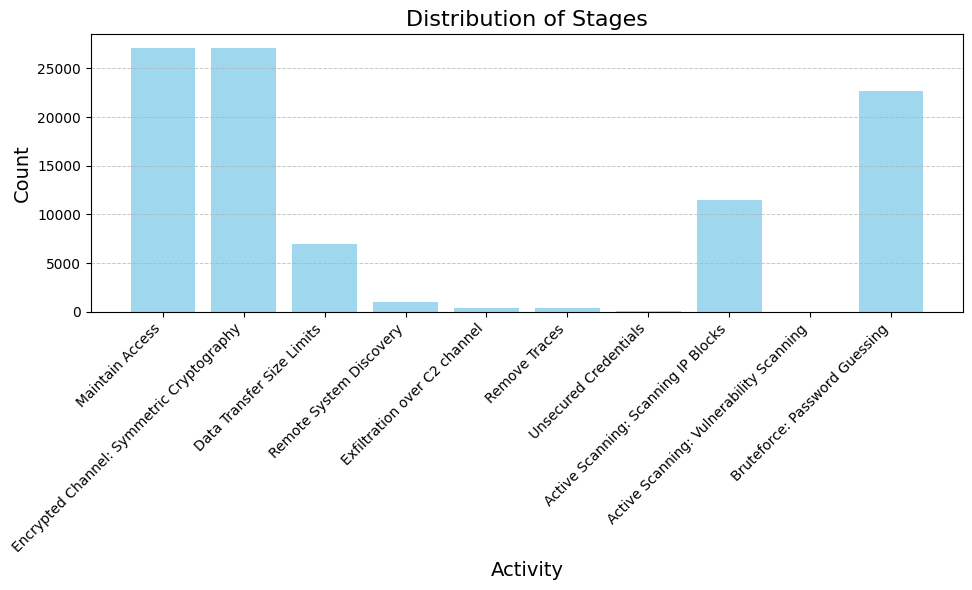

In [40]:
import matplotlib.pyplot as plt
# Đếm số lượng mẫu cho từng nhãn
stage_counts = df['Activity'].value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.bar(stage_counts.index, stage_counts.values, color='skyblue', alpha=0.8)

# Thêm nhãn, tiêu đề và lưới
plt.title('Distribution of Stages', fontsize=16)
plt.xlabel('Activity', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(ticks=stage_counts.index, labels=[
    'Maintain Access',
    'Encrypted Channel: Symmetric Cryptography',     
    'Data Transfer Size Limits',
    'Remote System Discovery',
    'Exfiltration over C2 channel',
    'Remove Traces',
    'Unsecured Credentials',
    'Active Scanning: Scanning IP Blocks',
    'Active Scanning: Vulnerability Scanning',
    'Bruteforce: Password Guessing'
], rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [41]:
df.value_counts('Activity')

Activity
0    27128
1    27111
9    22654
7    11450
2     6988
3     1002
4      446
5      362
6       88
8        5
Name: count, dtype: int64

In [42]:
from sklearn.utils import resample
import pandas as pd

# Định nghĩa số lượng mẫu mong muốn cho từng nhãn
desired_samples = {
    0: 3000,
    1: 3000,
    2: 3000,
    3: 1000,
    4: 1000,
    5: 1000,
    6: 300,
    7: 3000,
    8: 20,
    9: 3000
}

# Chia dữ liệu thành từng nhãn và resample theo số lượng mong muốn
df_balanced = pd.concat([
    resample(
        df[df['Activity'] == stage],
        n_samples=desired_samples[stage],  # Số lượng mẫu mong muốn
        random_state=42
    )
    for stage in desired_samples.keys()
])

# Kiểm tra kết quả
print(df_balanced['Activity'].value_counts())

Activity
0    3000
1    3000
2    3000
7    3000
9    3000
3    1000
5    1000
4    1000
6     300
8      20
Name: count, dtype: int64


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df_balanced.drop('Activity', axis=1)
y = df_balanced['Activity']
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [44]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
xgb_apt2021 = xgb.XGBClassifier(random_state = 42)

In [45]:
xgb_apt2021.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [46]:
y_pred = xgb_apt2021.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print(classification_report(y_test, y_pred))

0.9978165938864629
[[600   0   0   0   0   0   0   0   0   0]
 [  0 600   0   0   0   0   0   0   0   0]
 [  0   0 600   0   0   0   0   0   0   0]
 [  0   0   0 200   0   0   0   0   0   0]
 [  0   0   0   0 200   0   0   0   0   0]
 [  0   0   0   0   0 200   0   0   0   0]
 [  0   0   0   0   0   0  60   0   0   0]
 [  0   1   0   0   0   0   0 599   0   0]
 [  0   0   0   0   0   0   0   0   4   0]
 [  0   0   0   0   0   0   0   6   1 593]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       600
           1       1.00      1.00      1.00       600
           2       1.00      1.00      1.00       600
           3       1.00      1.00      1.00       200
           4       1.00      1.00      1.00       200
           5       1.00      1.00      1.00       200
           6       1.00      1.00      1.00        60
           7       0.99      1.00      0.99       600
           8       0.80      1.00      0.89         4
         

In [47]:
import joblib

# Lưu mô hình vào file
joblib.dump(xgb_apt2021, "D:/code/python/code/ScoreFactor/main/model/action_model.pkl")

print("✅ Mô hình đã được lưu thành công!")

✅ Mô hình đã được lưu thành công!


In [48]:
import joblib

xgb_apt2021_action = joblib.load("D:/code/python/code/ScoreFactor/action/predict_model.pkl")


FileNotFoundError: [Errno 2] No such file or directory: 'D:/code/python/code/ScoreFactor/action/predict_model.pkl'